# **MÓDULO 35 - Cross Validation**
## Detecção de incêndios

### Contexto

A detecção precoce de incêndios é um desafio crucial para a preservação ambiental e segurança humana. O monitoramento de variáveis atmosféricas e químicas, como temperatura, umidade, gases e partículas em suspensão, fornece indicadores importantes para prever a ocorrência de incêndios. Nesse cenário, técnicas de ciência de dados podem ser aplicadas para desenvolver modelos preditivos capazes de identificar padrões que antecedem esses eventos críticos. A validação adequada desses modelos garante maior confiabilidade e capacidade de generalização, fundamentais em aplicações de risco elevado como esta.

### 🎯 Objetivo Geral

Aplicar a técnica de **validação cruzada (cross-validation)** para avaliar a performance de um modelo de classificação na previsão da ocorrência de incêndios, utilizando variáveis ambientais coletadas em sensores.


### Objetivos Complementares

* **Pré-processamento pt-1:** Identificar variáveis relevantes, remover colunas não úteis (ex.: índice `Unnamed:0`) e tratar dados inconsistentes.
* **Modelagem:** Implementar modelos de classificação supervisionada (ex.: Regressão Logística, Random Forest, SVM), aplicando validação cruzada para comparar desempenhos.
* **Avaliação:** Medir métricas de performance (acurácia, precisão, recall, F1-score) com base nos folds da validação cruzada, verificando a robustez do modelo.

### 🗄️ Base de Dados

A base de dados contém variáveis ambientais e químicas utilizadas para prever a ocorrência de incêndios, conforme a **Tabela 1**.

| Feature         | Descrição                                             |
| --------------- | ----------------------------------------------------- |
| Unnamed:0       | Índice (não é uma variável útil para o modelo)        |
| UTC             | Tempo em Segundos UTC                                 |
| Temperature\[C] | Temperatura do Ar (°C)                                |
| Humidity\[%]    | Umidade do Ar (%)                                     |
| TVOC\[ppb]      | Compostos Orgânicos Voláteis totais (ppb)             |
| eCO2\[ppm]      | Concentração equivalente de CO₂ (ppm)                 |
| Raw H2          | Hidrogênio molecular bruto, não compensado            |
| Raw Ethanol     | Etanol gasoso bruto                                   |
| Pressure\[hPA]  | Pressão do Ar (hPa)                                   |
| PM1.0           | Material particulado < 1,0 µm                         |
| PM2.5           | Material particulado entre 1,0 µm e 2,5 µm            |
| NC0.5           | Concentração numérica de partículas < 0,5 µm          |
| NC1.0           | Concentração numérica de partículas 0,5–1,0 µm        |
| NC2.5           | Concentração numérica de partículas 1,0–2,5 µm        |
| CNT             | Contador de amostras                                  |
| **Fire Alarm**  | Variável alvo binária: 1 = incêndio, 0 = não incêndio |

**Tabela 1**

## 📂 1-Importação de Bibliotecas e Dataload 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Leitura dos dados
df = pd.read_csv("/home/akel/PycharmProjects/EBAC/dados/smoke_detection_iot.csv", delimiter=',')
df.head()

,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


In [2]:
# organizar gap temporal

df["delta"] = df["UTC"].diff().fillna(1)

# Calcular a correção acumulada (quando delta > 1)
df["corr"] = (df["delta"] - 1).where(df["delta"] != 1, 0).cumsum()
# Aplicar correção ao UTC
df["UTC_corrigido"] = df["UTC"] - df["corr"]

df["datetime"] = pd.to_datetime(df["UTC_corrigido"], unit="s")


Para a coluna Fire Alarm, por conta do espaçamento talvez seja util renomear o nome da coluna utilizando:

df.rename(columns={'Fire Alarm': 'Fire_Alarm'}, inplace=True)

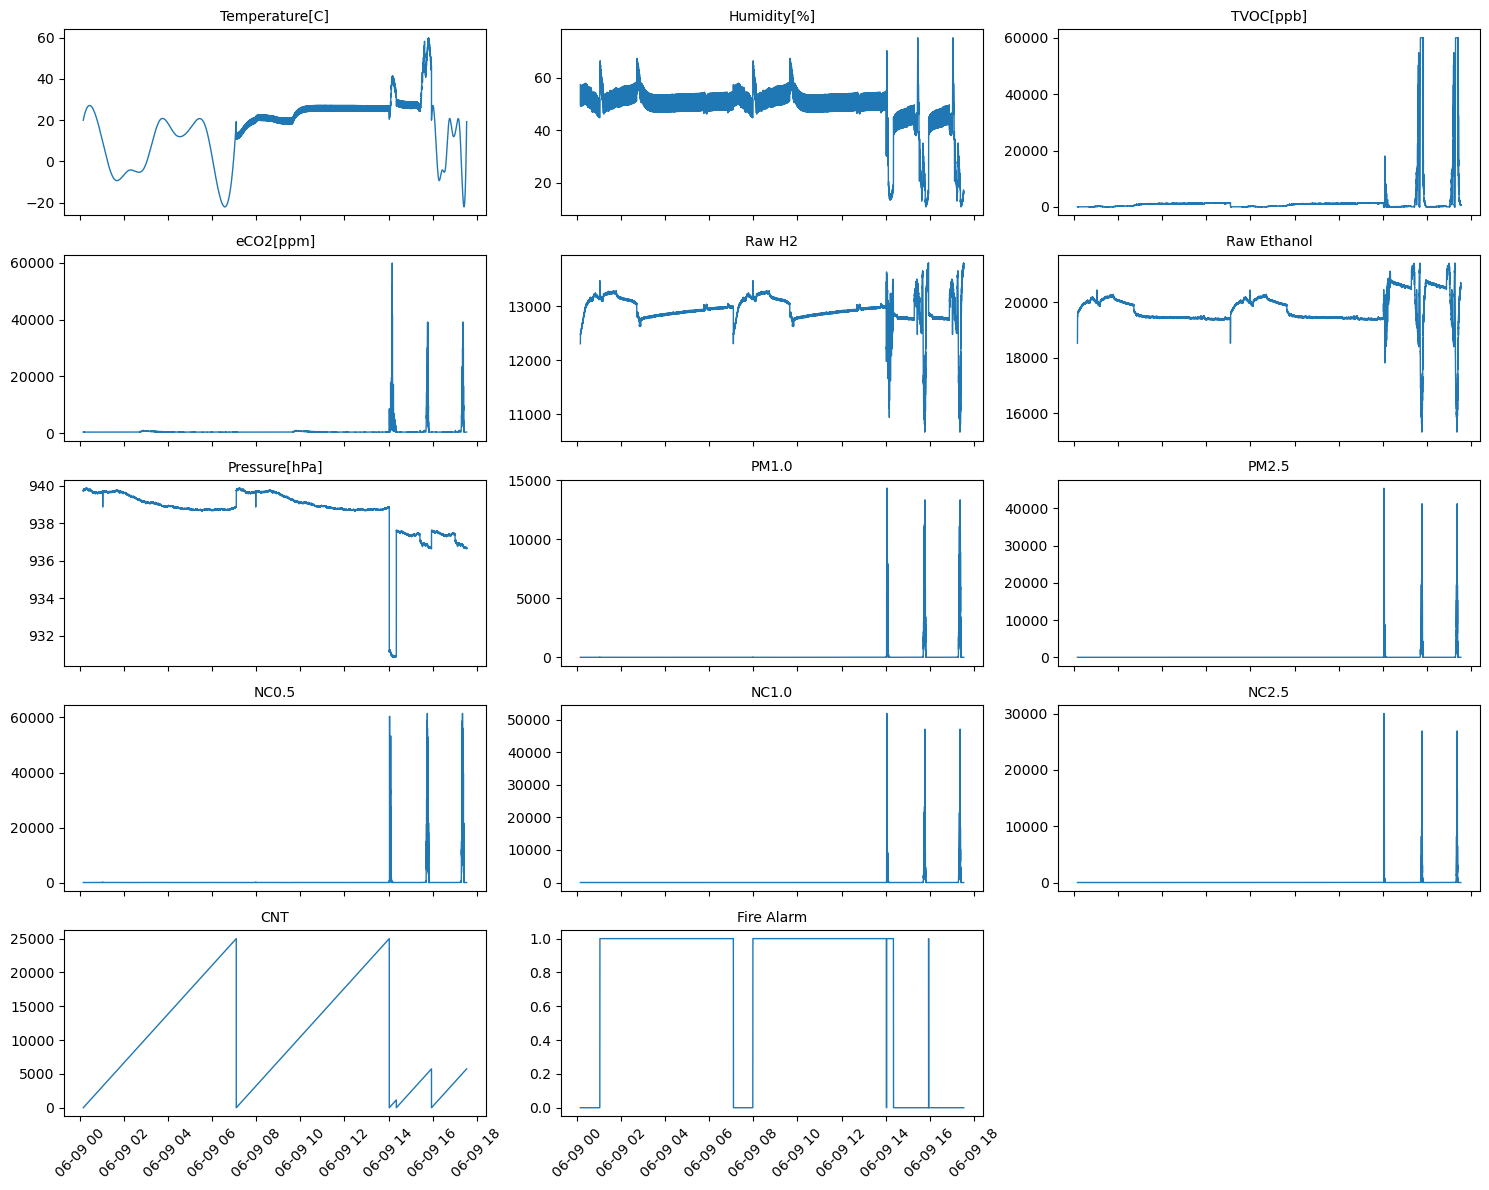

In [5]:

import seaborn as sns

# Definir datetime como índice

import matplotlib.pyplot as plt

# Definir colunas a serem analisadas
cols = [
    "Temperature[C]", "Humidity[%]", "TVOC[ppb]", "eCO2[ppm]",
    "Raw H2", "Raw Ethanol", "Pressure[hPa]",
    "PM1.0", "PM2.5",
    "NC0.5", "NC1.0", "NC2.5",
    "CNT", "Fire Alarm"
]

# Número de colunas por linha na grade de plots
ncols = 3
nrows = (len(cols) + ncols - 1) // ncols  # arredondar para cima

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 12), sharex=True)
axes = axes.flatten()  # transforma matriz de eixos em lista

for i, col in enumerate(cols):
    axes[i].plot(df['datetime'].values, df[col].values, lw=1)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis="x", rotation=45)

# Apaga subplots extras (se houver)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()
plt.show()

# 2 - Para essa base, onde você realizará as previsões de fire alarm, qual modelo de machine learning você aplicará? Justifique.




# 3 - Separe a base em Y e X e já rode a instância do modelo que você utilizará.

In [9]:
# seu código aqui

# 4 - Defina o número de Folds e rode o modelo com a validação cruzada.

In [11]:
# seu código aqui

# 5 - Avalie a pontuação de cada modelo e ao final a validação final da média.

In [16]:
# seu código aqui